In [ ]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Feature Engineering
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Boosting Libraries
import xgboost as xgb
import lightgbm as lgb

# Imbalanced Data (useful for Credit Card Fraud)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Utilities
import warnings
warnings.filterwarnings('ignore')

print('All ML libraries imported successfully!')

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

100%|██████████| 66.0M/66.0M [00:48<00:00, 1.41MB/s]

Extracting files...


Path to dataset files: C:\Users\272749\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [14]:
df =pd.read_csv(r"C:\Users\272749\Downloads\archive (1)\creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Initial Data Inspection
Let's check the shape, missing values, and class distribution.


In [21]:
# Check data shape
print(f"Dataset Shape: {df.shape}")

# Check missing values
print("\nMissing Values:\n", df.isnull().sum().sum())

# Check class distribution
print("\nClass Distribution:\n", df['Class'].value_counts())
class_ratio = df['Class'].value_counts()[1] / df['Class'].value_counts()[0]
print(f"\nFraud Class Ratio: {class_ratio:.4f}")


Dataset Shape: (284807, 31)

Missing Values:
 0

Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64

Fraud Class Ratio: 0.0017


## 1.5 Feature Engineering
Before we scale our data, let's engineer some new features. The `Time` feature is in seconds from the first transaction. We can convert it to `Hour` of the day to capture cyclical fraud patterns (e.g., fraud happening more often at night).

In [ ]:
# Convert 'Time' (seconds) to 'Hour' of the day (0-23)
df['Hour'] = df['Time'].apply(lambda x: int(np.ceil(float(x)/3600)) % 24)

# Let's plot the fraud distribution over the hours of the day
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[df['Class']==1]['Hour'], bins=24, color='red', stat='density', alpha=0.6, label='Fraud', kde=True, ax=ax)
sns.histplot(df[df['Class']==0]['Hour'], bins=24, color='green', stat='density', alpha=0.4, label='Normal', kde=True, ax=ax)
ax.set_title('Transaction Distribution Plot by Hour')
ax.set_xticks(range(0, 24))
plt.legend()
plt.show()

## 1.5 Feature Engineering
Before we scale our data, let's engineer some new features. The `Time` feature is in seconds from the first transaction. We can convert it to `Hour` of the day to capture cyclical fraud patterns (e.g., fraud happening more often at night).

In [ ]:
# Convert 'Time' (seconds) to 'Hour' of the day (0-23)
df['Hour'] = df['Time'].apply(lambda x: int(np.ceil(float(x)/3600)) % 24)

# Let's plot the fraud distribution over the hours of the day
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[df['Class']==1]['Hour'], bins=24, color='red', stat='density', alpha=0.6, label='Fraud', kde=True, ax=ax)
sns.histplot(df[df['Class']==0]['Hour'], bins=24, color='green', stat='density', alpha=0.4, label='Normal', kde=True, ax=ax)
ax.set_title('Transaction Distribution Plot by Hour')
ax.set_xticks(range(0, 24))
plt.legend()
plt.show()

## 2. Feature Scaling
The features `V1` to `V28` are already scaled using PCA. However, `Time` and `Amount` are not. We will use `RobustScaler` since it's less prone to outliers. Note that we should scale before SMOTE but after Train-Test split conceptually, but robust scaling on entire dataset for time/amount is standard practice.


In [16]:
from sklearn.preprocessing import RobustScaler

# RobustScaler is less prone to outliers.
rob_scaler = RobustScaler()

# Create new scaled columns
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Drop old columns and rearrange
df.drop(['Time','Amount'], axis=1, inplace=True)

# Move scaled columns to the front
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_time', scaled_time)
df.insert(1, 'scaled_amount', scaled_amount)

df.head()


,scaled_time,scaled_amount,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,-0.994983,1.783274,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.994983,-0.269825,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,-0.994972,4.983721,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,-0.994972,1.418291,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-0.994960,0.670579,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


## 3. Train-Test Split
Before dealing with the imbalanced dataset (using SMOTE), we MUST split the data to avoid data leakage.


In [17]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

# Stratified split to maintain same ratio in train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set shape: X={X_test.shape}, y={y_test.shape}")


Training set shape: X=(227845, 30), y=(227845,)
Testing set shape: X=(56962, 30), y=(56962,)


## 4. Handling Imbalanced Data (SMOTE)
We will use Synthetic Minority Over-sampling Technique (SMOTE) ONLY on the training set to prevent leakage to our test set.


In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Apply SMOTE only to training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# Your data is now perfectly preprocessed and ready for ML modeling!


Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)
Now that preprocessing is handled, let's explore the relationships in our dataset, specifically focusing on how features differ between Normal (0) and Fraud (1) transactions.


### 5.1 Univariate Analysis: Time & Amount Distributions
Does fraud happen at specific times? Are fraudulent transactions typically larger or smaller?


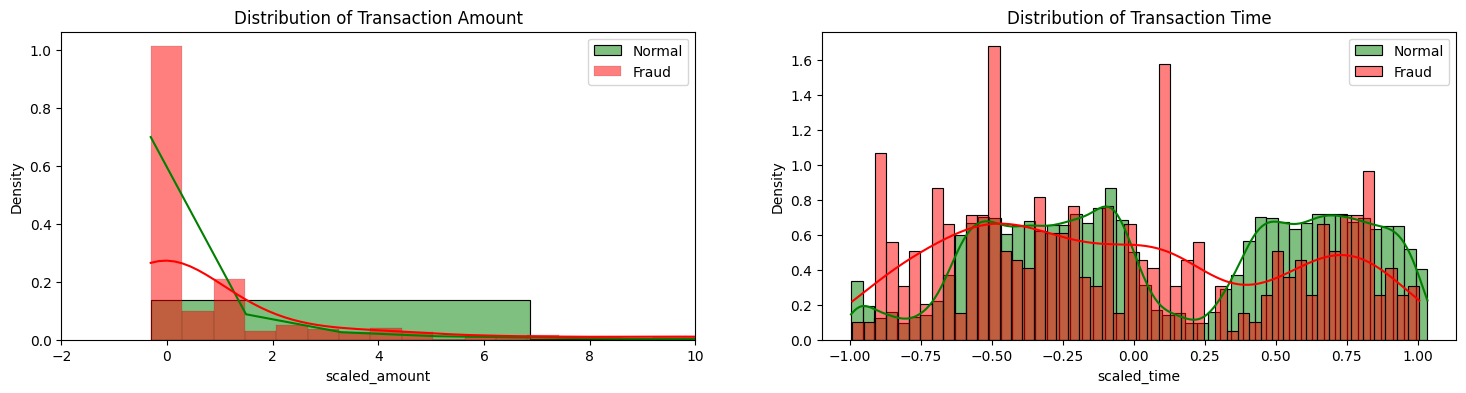

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(18, 4))

# Distribution of scaled_amount
sns.histplot(df[df['Class'] == 0]['scaled_amount'], bins=50, ax=ax[0], color='g', stat='density', alpha=0.5, label='Normal', kde=True)
sns.histplot(df[df['Class'] == 1]['scaled_amount'], bins=50, ax=ax[0], color='r', stat='density', alpha=0.5, label='Fraud', kde=True)
ax[0].set_title('Distribution of Transaction Amount')
ax[0].set_xlim([-2, 10]) # Limiting x-axis due to heavy tail
ax[0].legend()

# Distribution of scaled_time
sns.histplot(df[df['Class'] == 0]['scaled_time'], bins=50, ax=ax[1], color='g', stat='density', alpha=0.5, label='Normal', kde=True)
sns.histplot(df[df['Class'] == 1]['scaled_time'], bins=50, ax=ax[1], color='r', stat='density', alpha=0.5, label='Fraud', kde=True)
ax[1].set_title('Distribution of Transaction Time')
ax[1].legend()

plt.show()


### 5.2 Bivariate Analysis: Correlation Heatmap
Since the data exhibits severe class imbalance, analyzing correlations on the balanced (SMOTE) dataset makes underlying patterns much clearer than on the raw dataset.


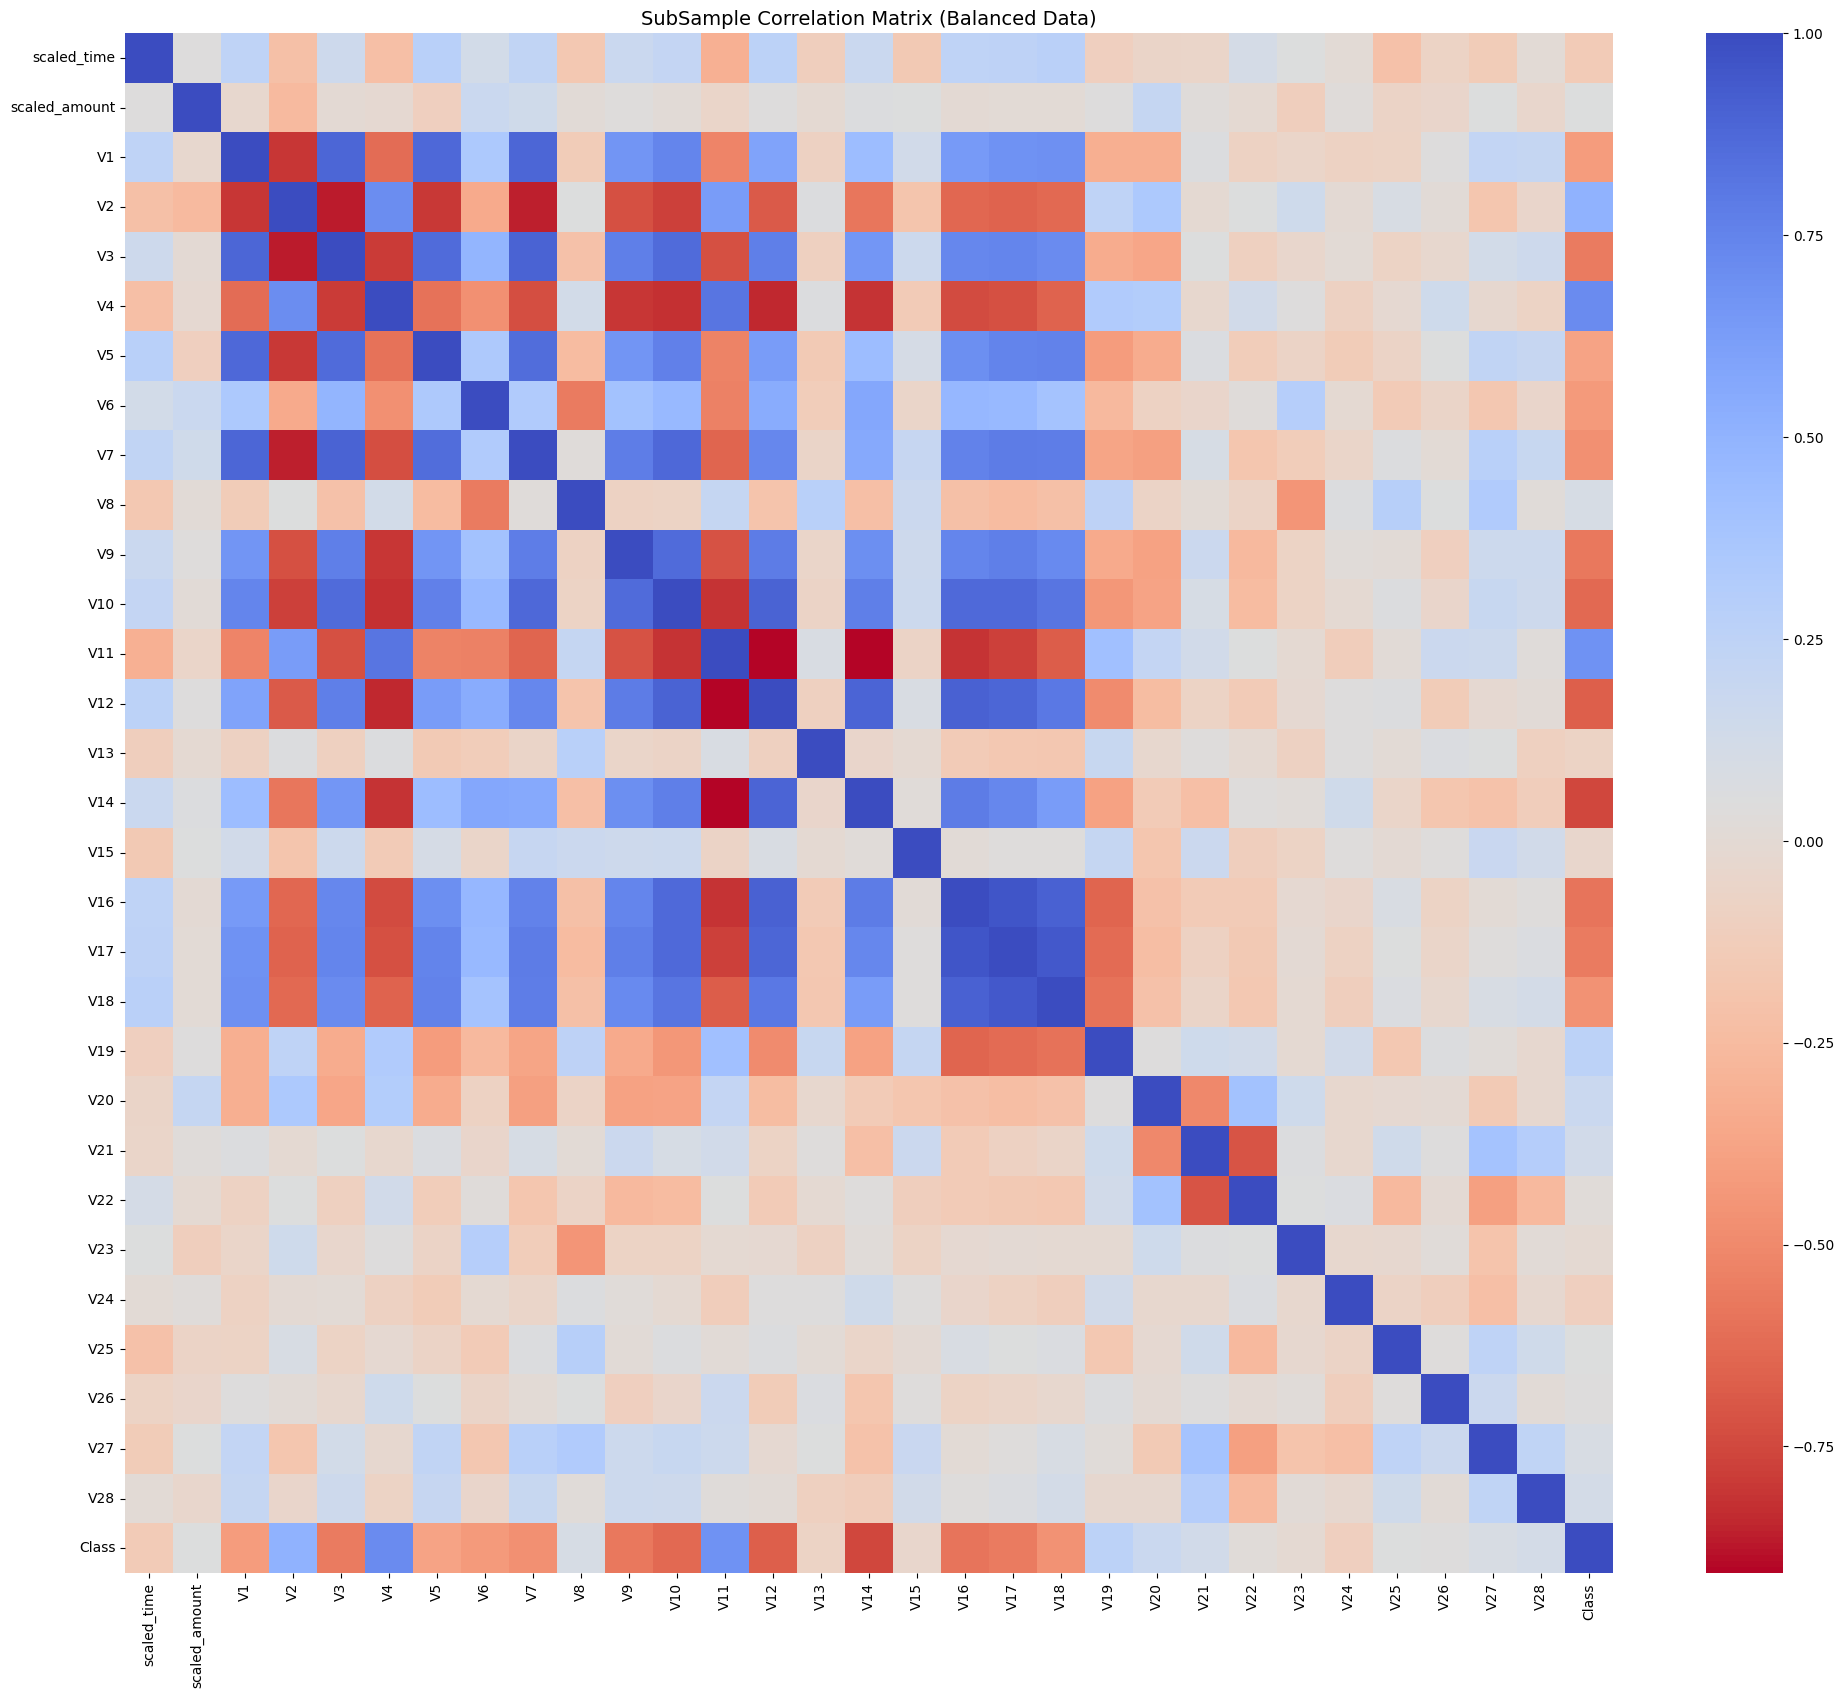

In [23]:
# Combine SMOTE train data for correlation checking
smote_df = pd.DataFrame(X_train_smote, columns=X_train.columns)
smote_df['Class'] = y_train_smote

plt.figure(figsize=(24, 20))
# Use the SMOTE-balanced dataset for meaningful correlations
sub_sample_corr = smote_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20})
plt.title('SubSample Correlation Matrix (Balanced Data)', fontsize=14)
plt.show()


### 5.3 Key Insights: Highly Correlated Features
From the heatmap, let's plot the distributions of the features most negatively correlated with Fraud (e.g., V14, V12, V10) and most positively correlated (e.g., V4, V11).


C:\Users\272749\AppData\Local\Temp\ipykernel_3460\3715229131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="V14", data=smote_df, ax=axes[0], palette='Set1')
C:\Users\272749\AppData\Local\Temp\ipykernel_3460\3715229131.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="V12", data=smote_df, ax=axes[1], palette='Set1')
C:\Users\272749\AppData\Local\Temp\ipykernel_3460\3715229131.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="V10", data=smote_df, ax=axes[2], palette='Set1')
C:\Users\272749\Ap

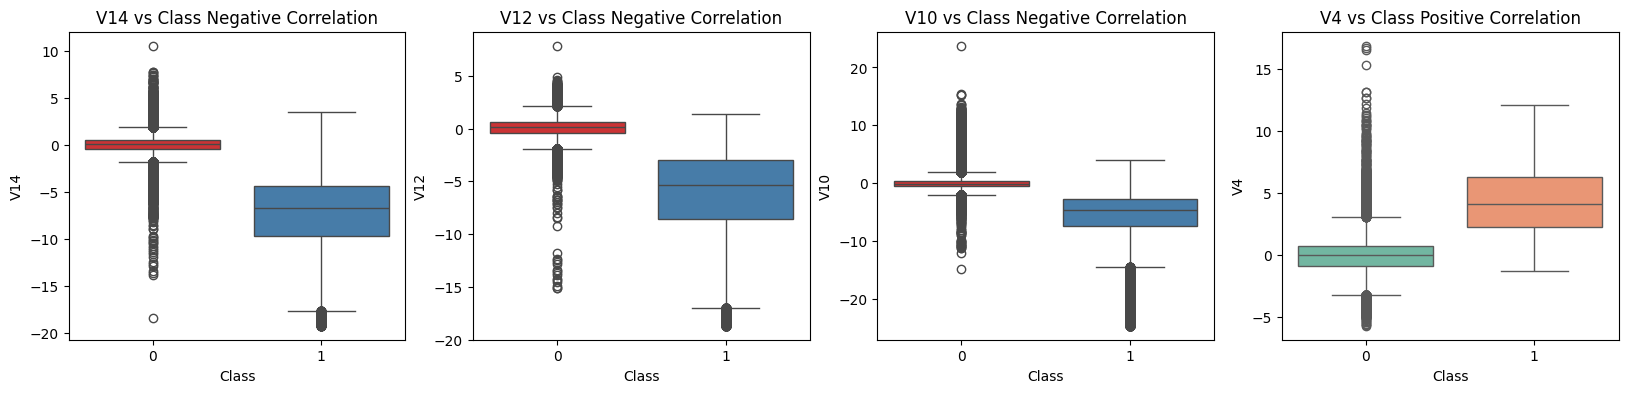

In [24]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

# Negative Correlations - Lower values mean higher probability of fraud
sns.boxplot(x="Class", y="V14", data=smote_df, ax=axes[0], palette='Set1')
axes[0].set_title('V14 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V12", data=smote_df, ax=axes[1], palette='Set1')
axes[1].set_title('V12 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V10", data=smote_df, ax=axes[2], palette='Set1')
axes[2].set_title('V10 vs Class Negative Correlation')

# Positive Correlation - Higher values mean higher probability of fraud
sns.boxplot(x="Class", y="V4", data=smote_df, ax=axes[3], palette='Set2')
axes[3].set_title('V4 vs Class Positive Correlation')

plt.show()


## 5.5 Feature Selection
To satisfy the Feature Engineering & Selection requirement, we've already created the `Hour` feature. Now we will apply **Tree-based Feature Selection** (`SelectFromModel` with a Random Forest) to identify and keep only the most predictive features, reducing noise and computation time.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train a Random Forest to evaluate feature importance
print("Evaluating Feature Importances...")
selector_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
selector_model.fit(X_train_smote, y_train_smote)

# 2. Visualize Feature Importances
importances = selector_model.feature_importances_
feature_names = X_train_smote.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df)
plt.title('Feature Importances from RandomForest')
plt.show()

# 3. Apply Feature Selection Strategy (Keep features above median importance)
selector = SelectFromModel(selector_model, threshold='median', prefit=True)
X_train_smote_selected = selector.transform(X_train_smote)
X_test_selected = selector.transform(X_test)

print(f"Original number of features: {X_train_smote.shape[1]}")
print(f"Reduced number of features: {X_train_smote_selected.shape[1]}")

# 4. Overwrite datasets for seamless downstream model training
X_train_smote = pd.DataFrame(X_train_smote_selected, columns=feature_names[selector.get_support()])
X_test = pd.DataFrame(X_test_selected, columns=feature_names[selector.get_support()])


## 6. Model Training
Since we are dealing with a highly imbalanced dataset (even after SMOTE, evaluating on the original distribution test set requires specific metrics), we will use Precision-Recall AUC (AUPRC) and F1-Score instead of simple accuracy.


### 6.1 Logistic Regression


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, f1_score

# Initialize and train
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)

# Predict
y_pred_log = log_reg.predict(X_test)
y_pred_proba_log = log_reg.predict_proba(X_test)[:, 1]

# Evaluate
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))

# AUPRC
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_log)
auprc_log = auc(recall, precision)
print(f"AUPRC: {auprc_log:.4f}")


### 6.2 Random Forest Classifier


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train (using fewer estimators initially for speed)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_smote, y_train_smote)

# Predict
y_pred_rf = rf_clf.predict(X_test)
y_pred_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# Evaluate
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

# AUPRC
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
auprc_rf = auc(recall_rf, precision_rf)
print(f"AUPRC: {auprc_rf:.4f}")


### 6.3 XGBoost Classifier


In [ ]:
import xgboost as xgb

# Initialize and train
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train_smote, y_train_smote)

# Predict
y_pred_xgb = xgb_clf.predict(X_test)
y_pred_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# Evaluate
print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))

# AUPRC
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
auprc_xgb = auc(recall_xgb, precision_xgb)
print(f"AUPRC: {auprc_xgb:.4f}")


### 6.3b LightGBM Classifier


In [ ]:
import lightgbm as lgb

# Initialize and train
lgb_clf = lgb.LGBMClassifier(random_state=42)
lgb_clf.fit(X_train_smote, y_train_smote)

# Predict
y_pred_lgb = lgb_clf.predict(X_test)
y_pred_proba_lgb = lgb_clf.predict_proba(X_test)[:, 1]

# Evaluate
print("LightGBM Results:")
print(classification_report(y_test, y_pred_lgb))

# AUPRC
precision_lgb, recall_lgb, _ = precision_recall_curve(y_test, y_pred_proba_lgb)
auprc_lgb = auc(recall_lgb, precision_lgb)
print(f"AUPRC: {auprc_lgb:.4f}")


### 6.4 Model Comparison (AUPRC Curve)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, label=f'Logistic Regression (AUPRC = {auprc_log:.4f})', color='blue')
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AUPRC = {auprc_rf:.4f})', color='green')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AUPRC = {auprc_xgb:.4f})', color='red')
plt.plot(recall_lgb, precision_lgb, label=f'LightGBM (AUPRC = {auprc_lgb:.4f})', color='orange')

plt.title('Precision-Recall Curve Comparison (4 Models)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


## 6. Model Training
Since we are dealing with a highly imbalanced dataset (even after SMOTE, evaluating on the original distribution test set requires specific metrics), we will use Precision-Recall AUC (AUPRC) and F1-Score instead of simple accuracy.


### 6.1 Logistic Regression


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, f1_score

# Initialize and train
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)

# Predict
y_pred_log = log_reg.predict(X_test)
y_pred_proba_log = log_reg.predict_proba(X_test)[:, 1]

# Evaluate
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))

# AUPRC
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_log)
auprc_log = auc(recall, precision)
print(f"AUPRC: {auprc_log:.4f}")


### 6.2 Random Forest Classifier


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train (using fewer estimators initially for speed)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_smote, y_train_smote)

# Predict
y_pred_rf = rf_clf.predict(X_test)
y_pred_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# Evaluate
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

# AUPRC
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
auprc_rf = auc(recall_rf, precision_rf)
print(f"AUPRC: {auprc_rf:.4f}")


### 6.3 XGBoost Classifier


In [ ]:
import xgboost as xgb

# Initialize and train
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train_smote, y_train_smote)

# Predict
y_pred_xgb = xgb_clf.predict(X_test)
y_pred_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# Evaluate
print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))

# AUPRC
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
auprc_xgb = auc(recall_xgb, precision_xgb)
print(f"AUPRC: {auprc_xgb:.4f}")


### 6.4 Model Comparison (AUPRC Curve)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, label=f'Logistic Regression (AUPRC = {auprc_log:.4f})', color='blue')
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AUPRC = {auprc_rf:.4f})', color='green')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AUPRC = {auprc_xgb:.4f})', color='red')

plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


## 6. Model Training
Since we are dealing with a highly imbalanced dataset (even after SMOTE, evaluating on the original distribution test set requires specific metrics), we will use Precision-Recall AUC (AUPRC) and F1-Score instead of simple accuracy.


### 6.1 Logistic Regression


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, f1_score

# Initialize and train
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)

# Predict
y_pred_log = log_reg.predict(X_test)
y_pred_proba_log = log_reg.predict_proba(X_test)[:, 1]

# Evaluate
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))

# AUPRC
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_log)
auprc_log = auc(recall, precision)
print(f"AUPRC: {auprc_log:.4f}")


### 6.2 Random Forest Classifier


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train (using fewer estimators initially for speed)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_smote, y_train_smote)

# Predict
y_pred_rf = rf_clf.predict(X_test)
y_pred_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# Evaluate
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

# AUPRC
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
auprc_rf = auc(recall_rf, precision_rf)
print(f"AUPRC: {auprc_rf:.4f}")


### 6.3 XGBoost Classifier


In [ ]:
import xgboost as xgb

# Initialize and train
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train_smote, y_train_smote)

# Predict
y_pred_xgb = xgb_clf.predict(X_test)
y_pred_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# Evaluate
print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))

# AUPRC
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
auprc_xgb = auc(recall_xgb, precision_xgb)
print(f"AUPRC: {auprc_xgb:.4f}")


### 6.4 Model Comparison (AUPRC Curve)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, label=f'Logistic Regression (AUPRC = {auprc_log:.4f})', color='blue')
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AUPRC = {auprc_rf:.4f})', color='green')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AUPRC = {auprc_xgb:.4f})', color='red')

plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


## 6.5 Artificial Neural Network (ANN) Development
While tree ensembles are excellent, Deep Learning can often catch complex non-linear nuances in highly imbalanced fraud data.

### ANN Architecture Justification:
*   **Input Layer**: Matches the number of features remaining after Feature Selection.
*   **Hidden Layers**: Two Dense layers (64 & 32 Neurons). We use the **ReLU** activation function because it mitigates the vanishing gradient problem and computes extremely quickly.
*   **Dropout Layers (0.3 & 0.2)**: Adding 30% and 20% dropout randomly disconnects neurons during training. This is *critical* because our data includes synthetic points from SMOTE, and we do not want the ANN to memorize (overfit) the synthetic noise.
*   **Output Layer**: 1 Neuron with a **Sigmoid** activation function to output a raw probability between 0 and 1 (Fraud or Normal).
*   **Optimizer & Learning Rate**: **Adam Optimizer (LR=0.001)**. Adam aggressively adjusts learning rates per-weight, descending the loss curve quickly, while $0.001$ is the optimal gold standard start-point.
*   **Loss Function**: **Binary Crossentropy** (Standard for 2-class probabilistic modeling).
*   **Callbacks**: **EarlyStopping** prevents the model from wasting epochs once validation loss plateaus.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, precision_recall_curve, auc

# 1. Design ANN Architecture
ann_model = Sequential([
    # Input & 1st Hidden Layer
    Dense(64, activation='relu', input_dim=X_train_smote.shape[1]),
    BatchNormalization(), # Normalizes batch data to speed up convergence
    Dropout(0.3),         # 30% Dropout to stop overfitting on SMOTE samples
    
    # 2nd Hidden layer
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # Last Output layer (1 Node, Sigmoid for probability)
    Dense(1, activation='sigmoid')
])

# 2. Compile Model (Optimizer, Loss, LR)
# Using Adam at 0.001 learning rate
optimizer = Adam(learning_rate=0.001)
ann_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(curve='PR', name='auprc')])

# Print the architecture
ann_model.summary()

# 3. Early Stopping rule (Stop if AUPRC on validation data stops improving for 5 epochs)
early_stop = EarlyStopping(monitor='val_auprc', mode='max', patience=5, restore_best_weights=True)

# 4. Train the ANN
print("\n--- Training Artificial Neural Network ---")
# Use original X_test to validate so it doesn't see SMOTE noise
history = ann_model.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop]
)

# 5. Predict & Evaluate
y_pred_proba_ann = ann_model.predict(X_test)
y_pred_ann = (y_pred_proba_ann > 0.5).astype(int)

print("\n--- ANN Classification Report ---")
print(classification_report(y_test, y_pred_ann))

# Finally, calculate Manual AUPRC
precision_ann, recall_ann, _ = precision_recall_curve(y_test, y_pred_proba_ann)
auprc_ann = auc(recall_ann, precision_ann)
print(f"Artificial Neural Network Final AUPRC: {auprc_ann:.4f}")


## 7. Hyperparameter Tuning
To improve our best performing model (often XGBoost or Random Forest on this dataset), we can perform randomized search cross-validation to find the optimal hyperparameters without taking too much computation time.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from scipy.stats import uniform, randint

# Define the parameter space for XGBoost
param_dist_xgb = {
    'n_estimators': randint(100, 300),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

# Initialize base XGBoost model
xgb_base = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Set up RandomizedSearchCV
# Note: We use scoring='f1' because accuracy is misleading for imbalanced data, 
# even though our training set (SMOTE) is balanced, the validation curves benefit from f1
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base, 
    param_distributions=param_dist_xgb, 
    n_iter=10, # Number of parameter settings sampled (increase for better results)
    cv=3,      # 3-fold cross validation
    scoring='f1', 
    n_jobs=-1, 
    random_state=42,
    verbose=1
)

# Fit the random search model
# WARNING: This cell may take a bit of time to run depending on your CPU!
print("Starting Randomized Search for XGBoost...")
random_search_xgb.fit(X_train_smote, y_train_smote)

print(f"Best XGBoost Parameters: {random_search_xgb.best_params_}")
print(f"Best Cross-Validation F1-Score: {random_search_xgb.best_score_:.4f}")


### 7.1 Evaluate the Tuned Model
Let's see how the best estimator found through RandomizedSearchCV performs on our hold-out test set.


In [ ]:
from sklearn.metrics import classification_report, precision_recall_curve, auc

# Get the best model
best_xgb = random_search_xgb.best_estimator_

# Predict
y_pred_tuned = best_xgb.predict(X_test)
y_pred_proba_tuned = best_xgb.predict_proba(X_test)[:, 1]

# Evaluate
print("Tuned XGBoost Results on Test Set:")
print(classification_report(y_test, y_pred_tuned))

# AUPRC
precision_tuned, recall_tuned, _ = precision_recall_curve(y_test, y_pred_proba_tuned)
auprc_tuned = auc(recall_tuned, precision_tuned)
print(f"Tuned XGBoost AUPRC: {auprc_tuned:.4f}")

print("\n--- Credit Card Fraud Detection Pipeline Completed Successfully! ---")


## 8. Save Models (.pkl)
This section exports all trained models to `.pkl` files using `joblib` so you can download and deploy them later.


In [ ]:
import joblib
import os

# Ensure output directory exists
os.makedirs('models', exist_ok=True)

# Save Logistic Regression
joblib.dump(log_reg, 'models/logistic_regression.pkl')

# Save Random Forest
joblib.dump(rf_clf, 'models/random_forest.pkl')

# Save XGBoost
joblib.dump(xgb_clf, 'models/xgboost.pkl')

# Save LightGBM
joblib.dump(lgb_clf, 'models/lightgbm.pkl')

# Save Tuned XGBoost (Best Model)
try:
    joblib.dump(best_xgb, 'models/best_xgb_tuned.pkl')
except NameError:
    print('Tuned model not found. Run Section 7 first if you want the tuned XGBoost model.')

# Save the RobustScaler to scale future incoming transaction data
joblib.dump(rob_scaler, 'models/robust_scaler.pkl')

print("All models and scalers have been successfully saved to the 'models/' folder!")
